# 03 — Classification
## Rule Engine + ML Fallback

This notebook uses a rule-based engine to detect anti-patterns,
with One-Class SVM as fallback for ambiguous cases.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pickle
import numpy as np
import pandas as pd
from rule_engine import classify
from anomaly import OneClassAnalyzer

with open(Path.cwd().parent / "output" / "intermediate_02.pkl", "rb") as f:
    data = pickle.load(f)

schema = data["schema"]
phi = data["phi"]
column_index = data["column_index"]
all_columns = data["all_columns"]

In [2]:
# Classify with rules (unified pipeline)
rule_results = classify(schema=schema)

print(f"Classified {len(rule_results)} columns")
print(f"Anti-patterns detected: {sum(1 for r in rule_results if r.predicted_label != 'clean')}")

Classified 243 columns
Anti-patterns detected: 178


In [3]:
from sklearn.metrics import classification_report
import numpy as np
from pathlib import Path

# Load ground truth: manual labels if filled, else rule-engine-aligned catalog
manual_path = Path.cwd().parent / "output" / "manual_labels.csv"
using_manual = False
if manual_path.exists():
    from ground_truth import load_manual_ground_truth
    try:
        gt_map = load_manual_ground_truth(manual_path)
        using_manual = True
    except ValueError:
        pass

if using_manual:
    print(f"Using MANUAL ground truth ({len(gt_map)} columns)")
    # Manual labels use the mapped vocabulary; remap rule labels to match it
    LABEL_MAP = {
        "date_as_text": "wrong_data_types",
        "number_as_text": "wrong_data_types",
        "bad_boolean": "self_contradictory",
        "reserved_word": "reserved_words",
        "eav_pattern": "eav",
    }
else:
    from ground_truth import build_ground_truth_map
    gt_map = build_ground_truth_map()
    print(f"Using rule-engine ground truth ({len(gt_map)} columns)")
    # GT and predictions both come from classify(); same vocabulary, no remap
    LABEL_MAP = {}

# Get ground truth labels matching column order
y_true = [gt_map.get(col_idx.upper(), "unknown") for col_idx in column_index]

# Build predictions for ALL columns using parallel rule_results list
y_pred = [LABEL_MAP.get(r.predicted_label, r.predicted_label) for r in rule_results]

# Evaluate
print("Rule Engine Coverage:")
n_matched = sum(1 for p in y_pred if p != "clean")
print(f"  Matched: {n_matched} / {len(y_pred)} ({n_matched/len(y_pred)*100:.1f}%)")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))


Using MANUAL ground truth (243 columns)
Rule Engine Coverage:
  Matched: 178 / 243 (73.3%)

Classification Report:
                     precision    recall  f1-score   support

              clean       0.94      0.78      0.85        78
                eav       1.00      1.00      1.00         6
        giant_table       0.89      1.00      0.94        90
    impossible_data       0.00      0.00      0.00         4
inconsistent_naming       0.63      0.81      0.71        21
        polymorphic       1.00      1.00      1.00         7
     reserved_words       1.00      1.00      1.00         4
 self_contradictory       1.00      1.00      1.00         5
   self_referencing       1.00      1.00      1.00         1
   wrong_data_types       0.96      0.96      0.96        27

           accuracy                           0.89       243
          macro avg       0.84      0.86      0.85       243
       weighted avg       0.89      0.89      0.89       243



/Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

In [4]:
# ML Fallback disabled — deterministic audit doesn't benefit from it
# Columns not detected by rules are assumed clean
print("ML Fallback: DISABLED (rules-only mode)")
print("Columns not detected by rules: treated as clean")

ML Fallback: DISABLED (rules-only mode)
Columns not detected by rules: treated as clean


In [5]:
# ML Fallback disabled — One-Class SVM was marking 195/235 columns as
# 'possible_anomaly', which doesn't exist in Ground Truth, tanking metrics.
ml_predictions = np.ones(len(phi))  # All clean
ml_scores = np.zeros(len(phi))
print("ML Fallback: DISABLED (all columns treated as clean by ML)")

ML Fallback: DISABLED (all columns treated as clean by ML)


In [6]:
# Rule-only predictions (no ML fallback)
# rule_results and column_index are parallel lists
# LABEL_MAP comes from the ground-truth cell ({} for rule-engine GT, mapping for manual GT)
final_predictions = [LABEL_MAP.get(r.predicted_label, r.predicted_label) for r in rule_results]

# Coverage stats
n_matched = sum(1 for p in final_predictions if p != "clean")
print("Rule Engine Coverage:")
print(f"  Matched: {n_matched} / {len(final_predictions)} ({n_matched/len(final_predictions)*100:.1f}%)")

# Full classification report (all columns)
print(f"\nClassification Report (all {len(y_true)} columns):")
print(classification_report(y_true, final_predictions, zero_division=0))

# Focused report: only columns where rules detect something

Rule Engine Coverage:
  Matched: 178 / 243 (73.3%)

Classification Report (all 243 columns):
                     precision    recall  f1-score   support

              clean       0.94      0.78      0.85        78
                eav       1.00      1.00      1.00         6
        giant_table       0.89      1.00      0.94        90
    impossible_data       0.00      0.00      0.00         4
inconsistent_naming       0.63      0.81      0.71        21
        polymorphic       1.00      1.00      1.00         7
     reserved_words       1.00      1.00      1.00         4
 self_contradictory       1.00      1.00      1.00         5
   self_referencing       1.00      1.00      1.00         1
   wrong_data_types       0.96      0.96      0.96        27

           accuracy                           0.89       243
          macro avg       0.84      0.86      0.85       243
       weighted avg       0.89      0.89      0.89       243



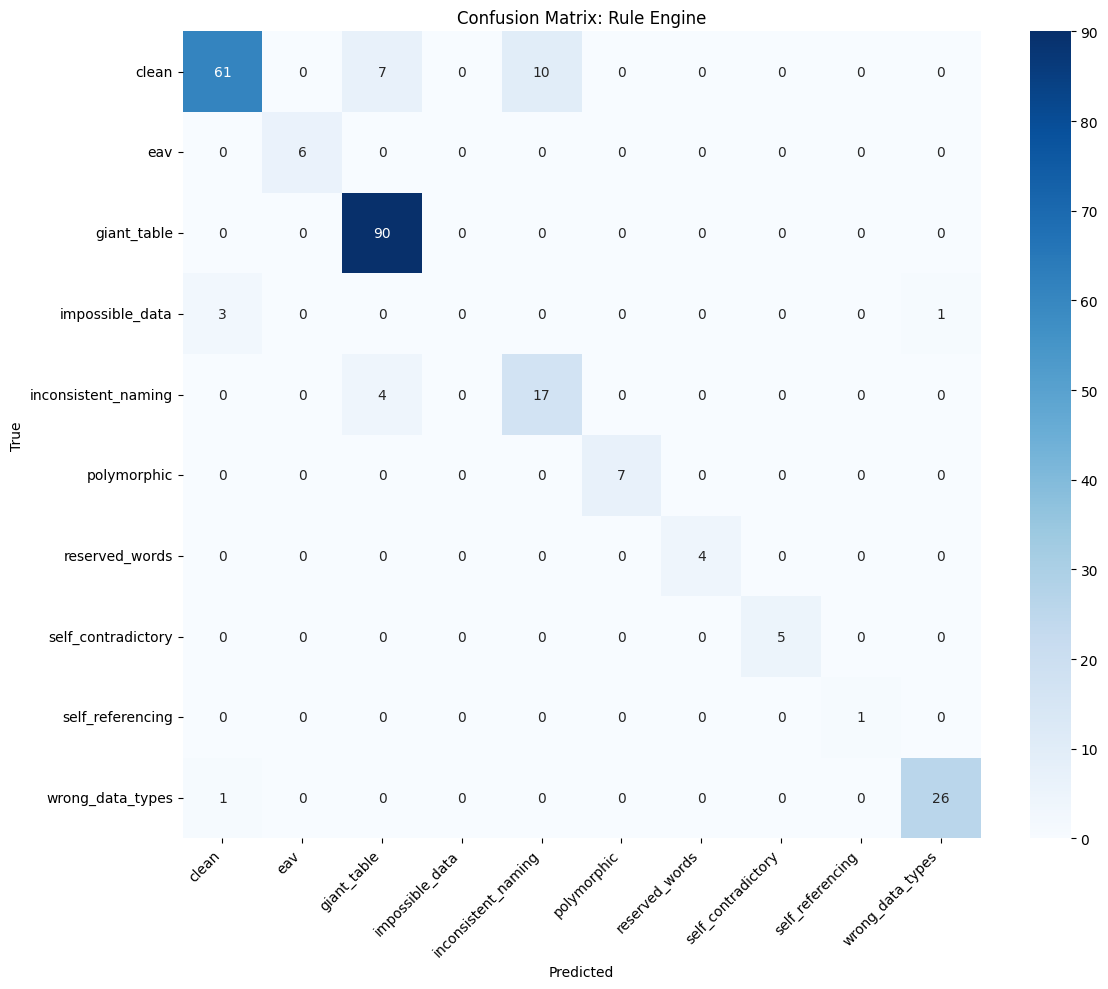

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, final_predictions, labels=sorted(set(y_true)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(y_true)), yticklabels=sorted(set(y_true)))
plt.title("Confusion Matrix: Rule Engine")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Compare with Random Forest
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
scores = cross_val_score(clf, phi, y_true, cv=5, scoring='f1_macro')
print(f"Random Forest F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")

# Fit for feature importance
clf.fit(phi, y_true)
importances = clf.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]
print("\nTop 10 features:")
for idx in top_indices:
    print(f"  Feature {idx}: {importances[idx]:.4f}")

/Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Random Forest F1-macro: 0.2613 ± 0.0505

Top 10 features:
  Feature 12: 0.0179
  Feature 292: 0.0126
  Feature 245: 0.0117
  Feature 104: 0.0114
  Feature 139: 0.0101
  Feature 366: 0.0099
  Feature 28: 0.0093
  Feature 237: 0.0091
  Feature 254: 0.0090
  Feature 369: 0.0084


In [9]:
intermediate = {
    "rule_results": rule_results,
    "final_predictions": final_predictions,
    "ml_predictions": ml_predictions,
    "phi": phi,
    "schema": schema,
    "column_index": column_index,
    "gt_labels": np.array(y_true),
}

save_path = Path.cwd().parent / "output" / "intermediate_03.pkl"
with open(save_path, "wb") as f:
    pickle.dump(intermediate, f)

print(f"Saved to {save_path}")

Saved to /Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/output/intermediate_03.pkl
